In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=50
mu_prior_mean=0
mu_prior_std=1
likelihood_std=1

In [3]:
# simulator
def prior():
    mu = RNG.normal(loc=mu_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [4]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [5]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=6 * num_dims
)

inference_net = bf.networks.CouplingFlow()

In [6]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [7]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 25.1021
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 18.9108
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 13.8275
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 10.3575
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 8.3241
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 6.1421
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 4.2385
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.8889
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.4996
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: -0.0320
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -1.1434
Epoch 12/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -1.7659
Epoch 13/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: -2.2986
Epoch 14/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -2.7875
Epoch 15/100
128/128

INFO:bayesflow:Training completed in 5.54 minutes.


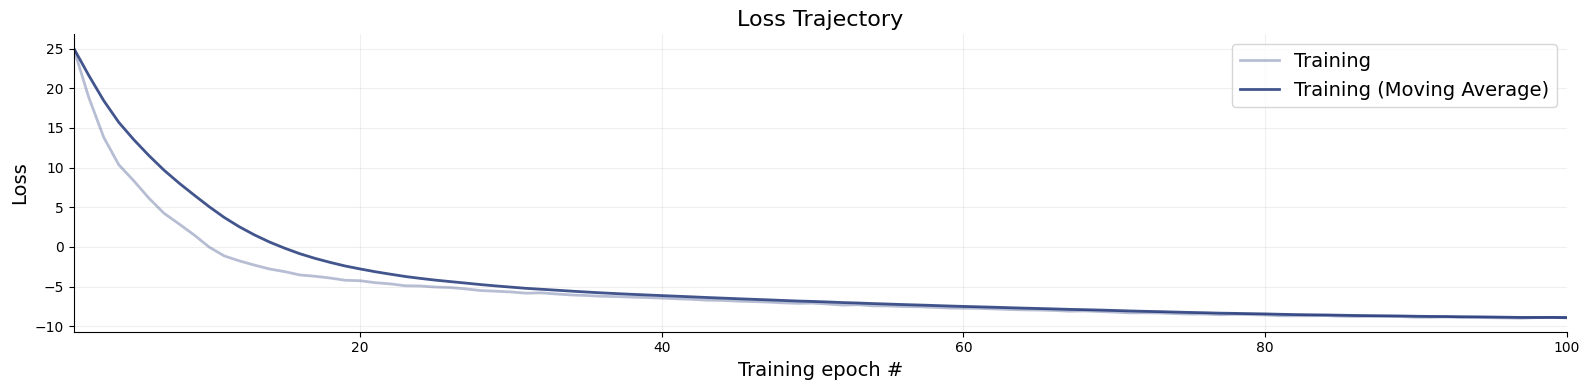

In [8]:
f=bf.diagnostics.plots.loss(history)

In [9]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 1.54 seconds.


dict_keys(['mu'])

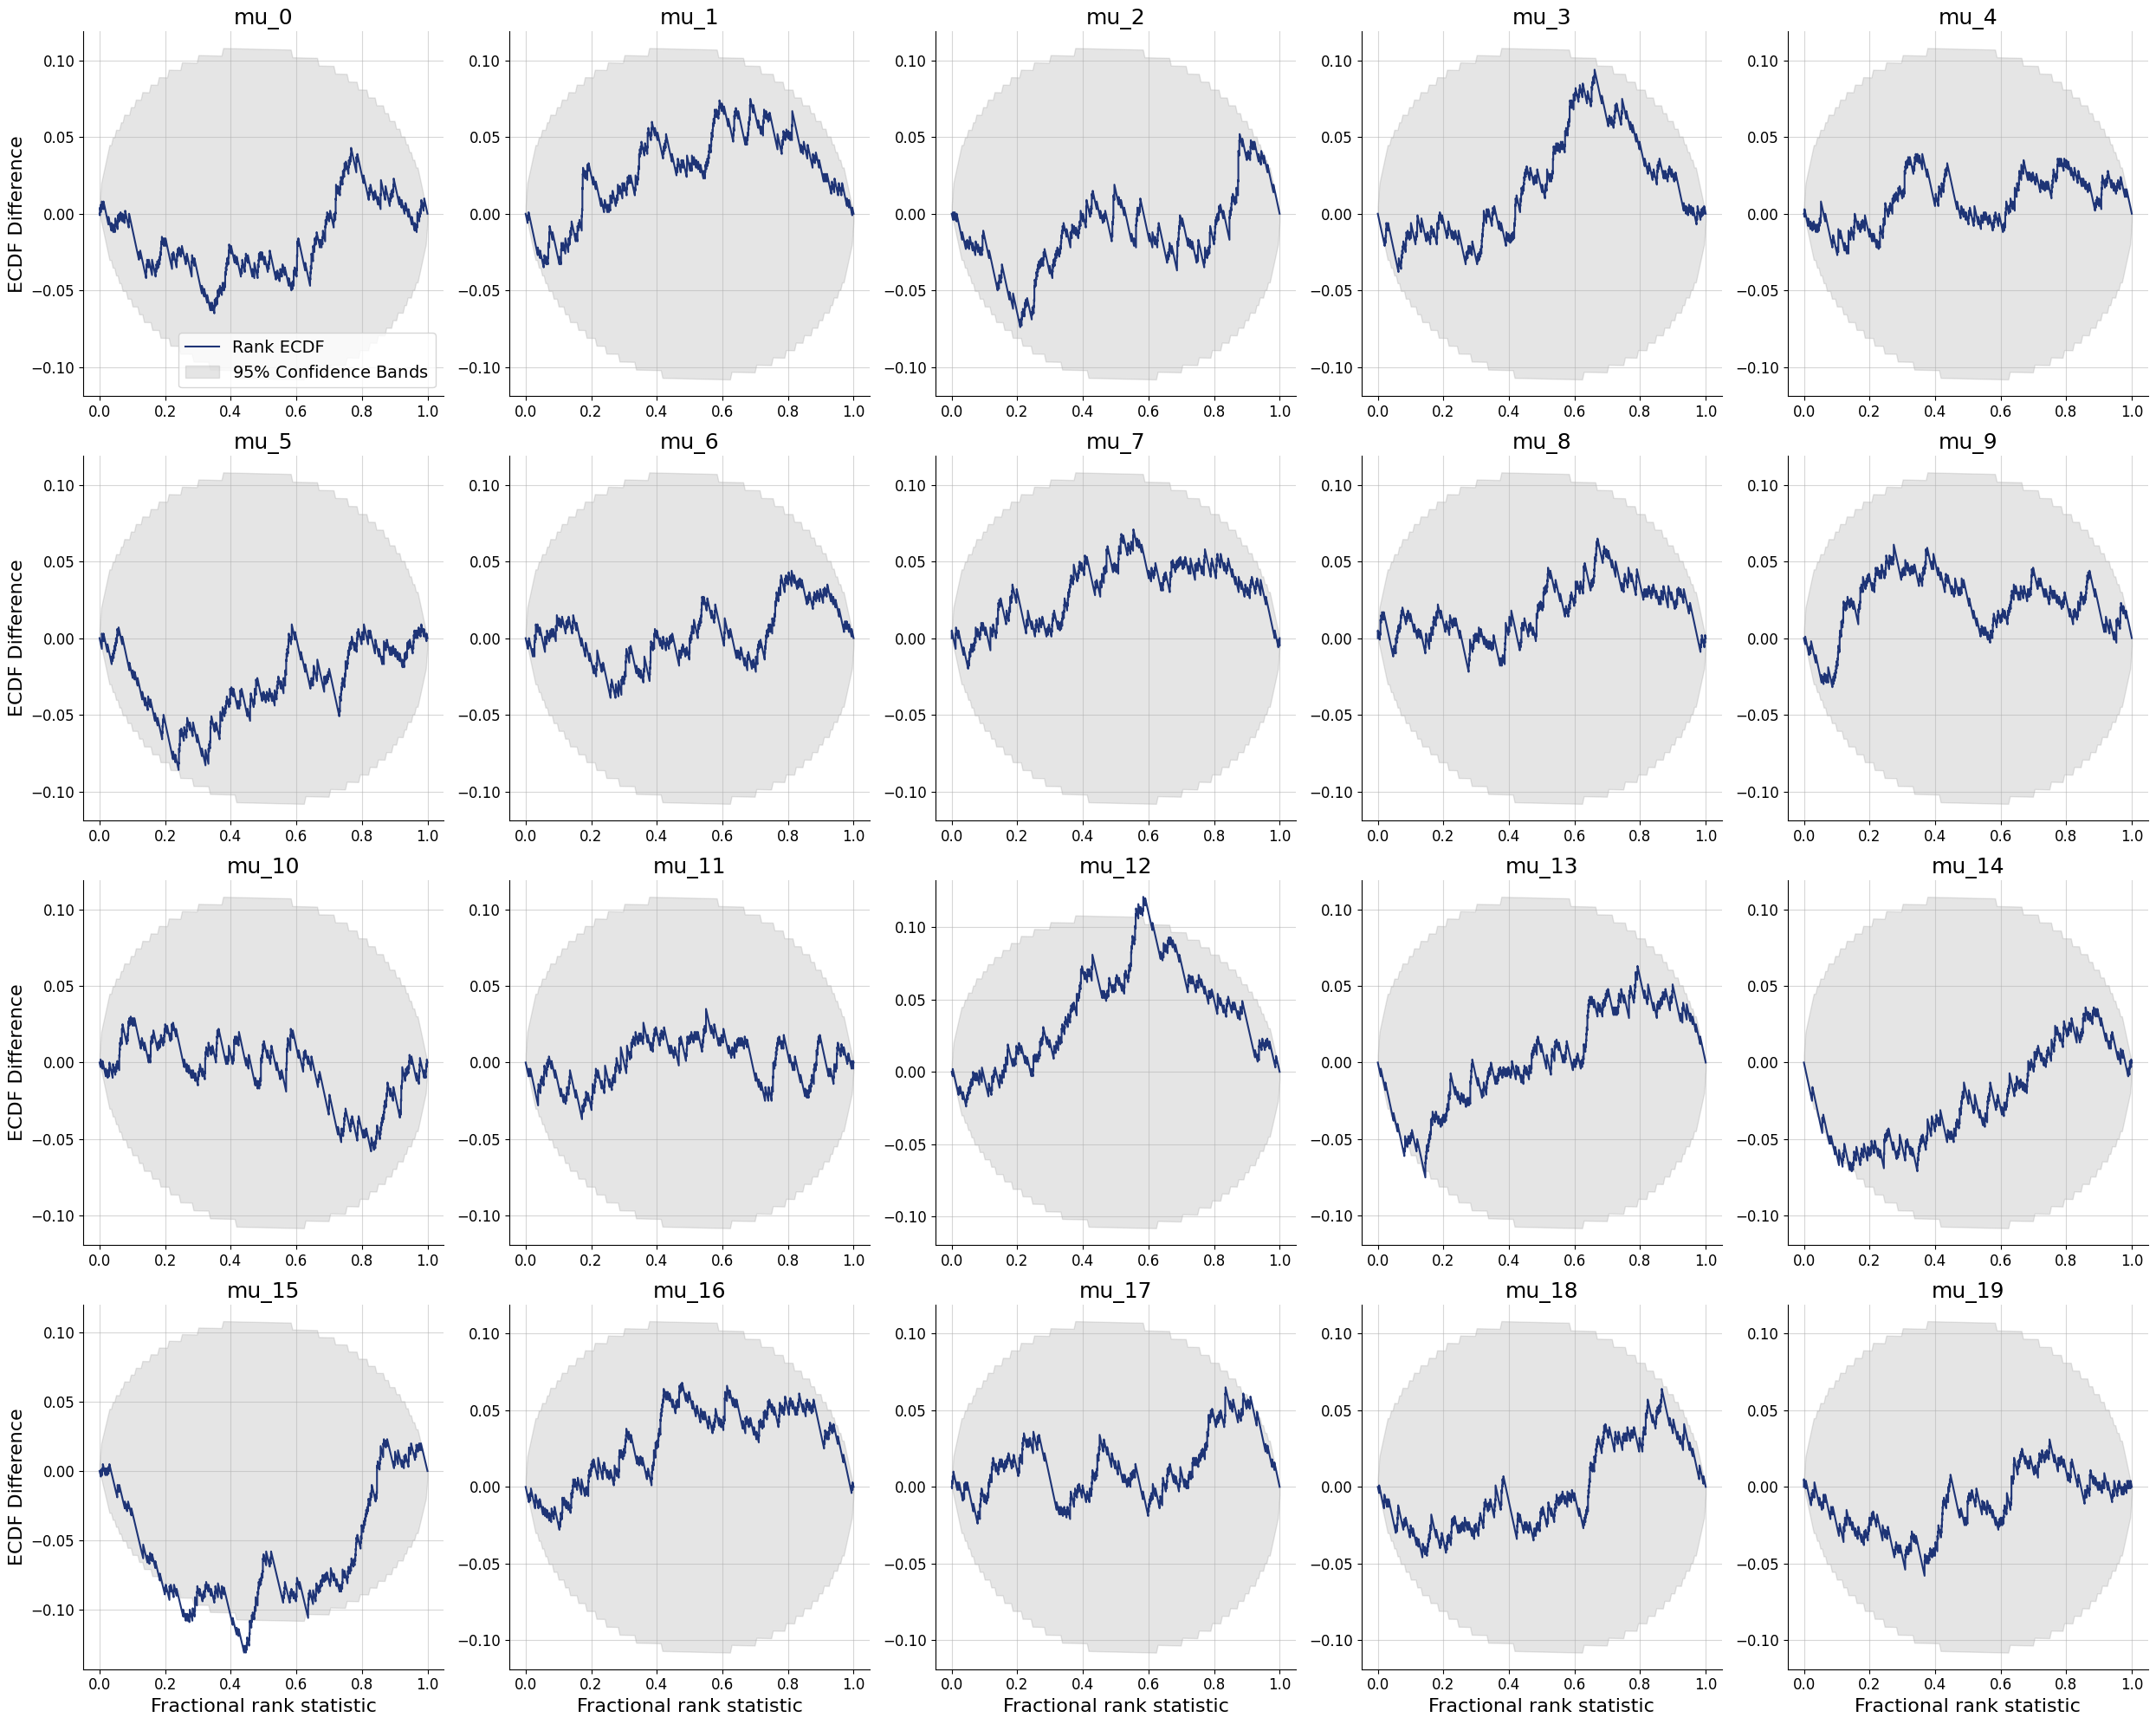

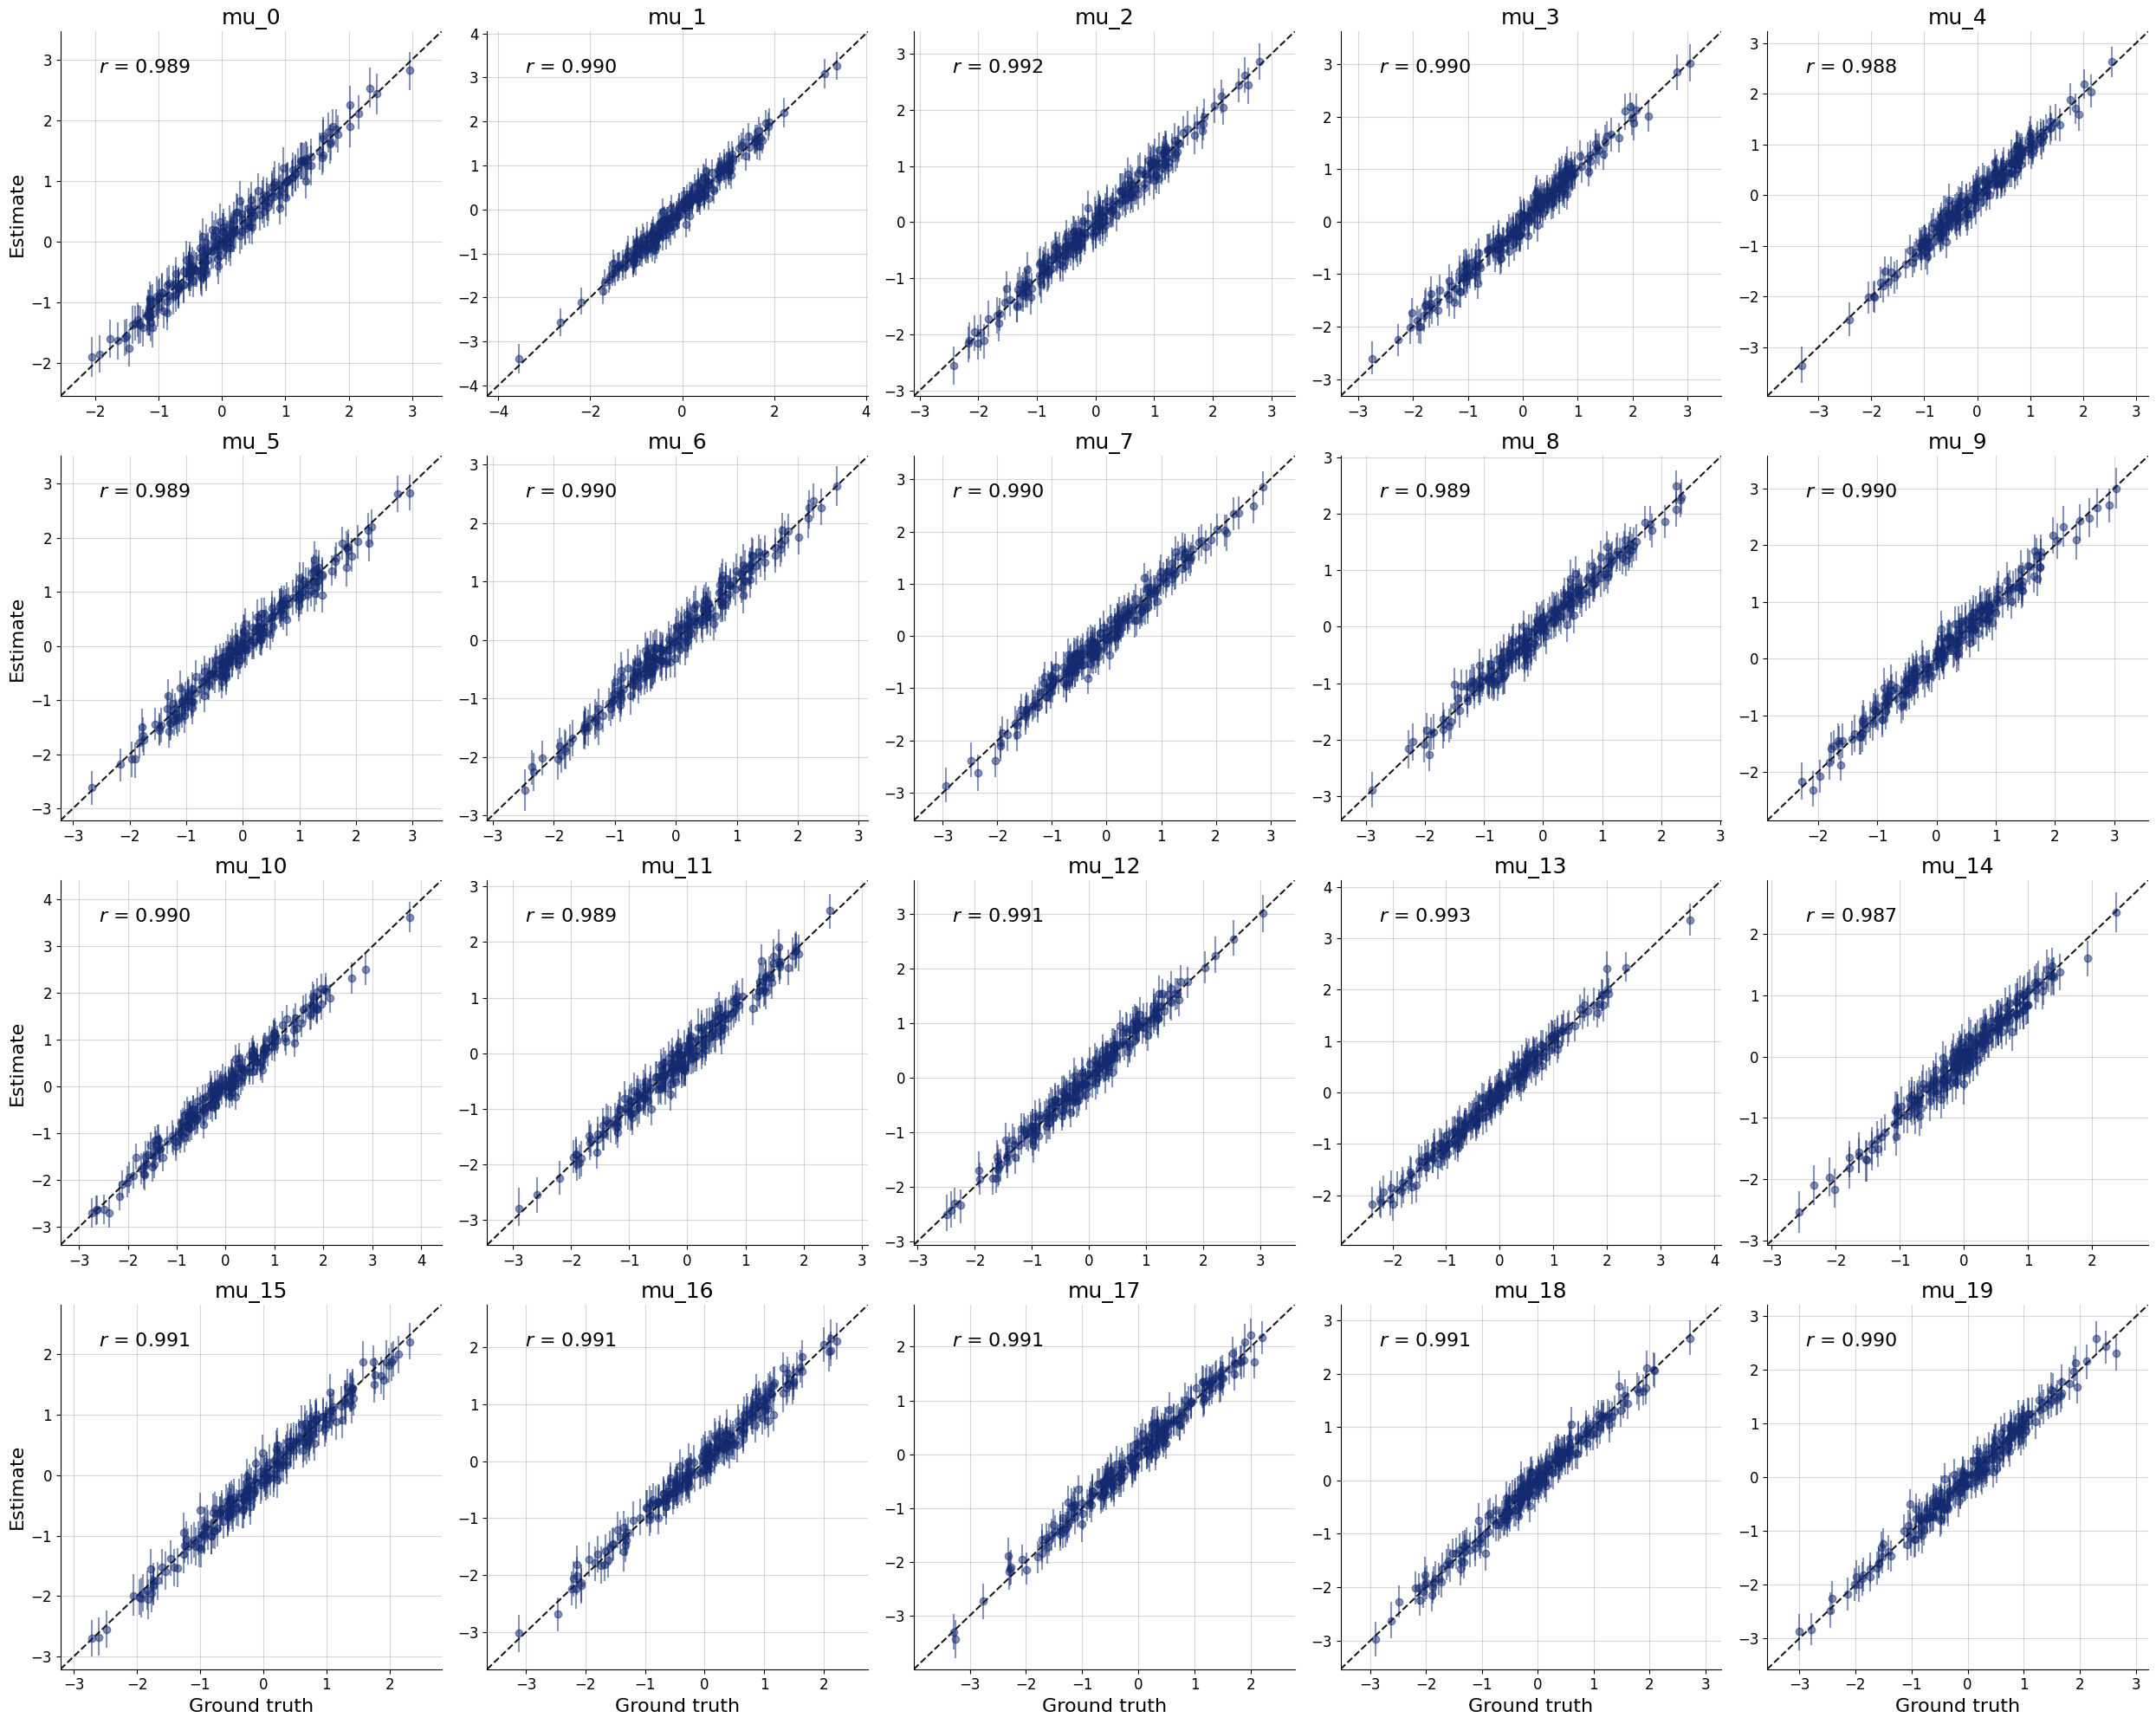

In [10]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [11]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m1.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [12]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m1.keras"
approximator = keras.saving.load_model(filepath)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

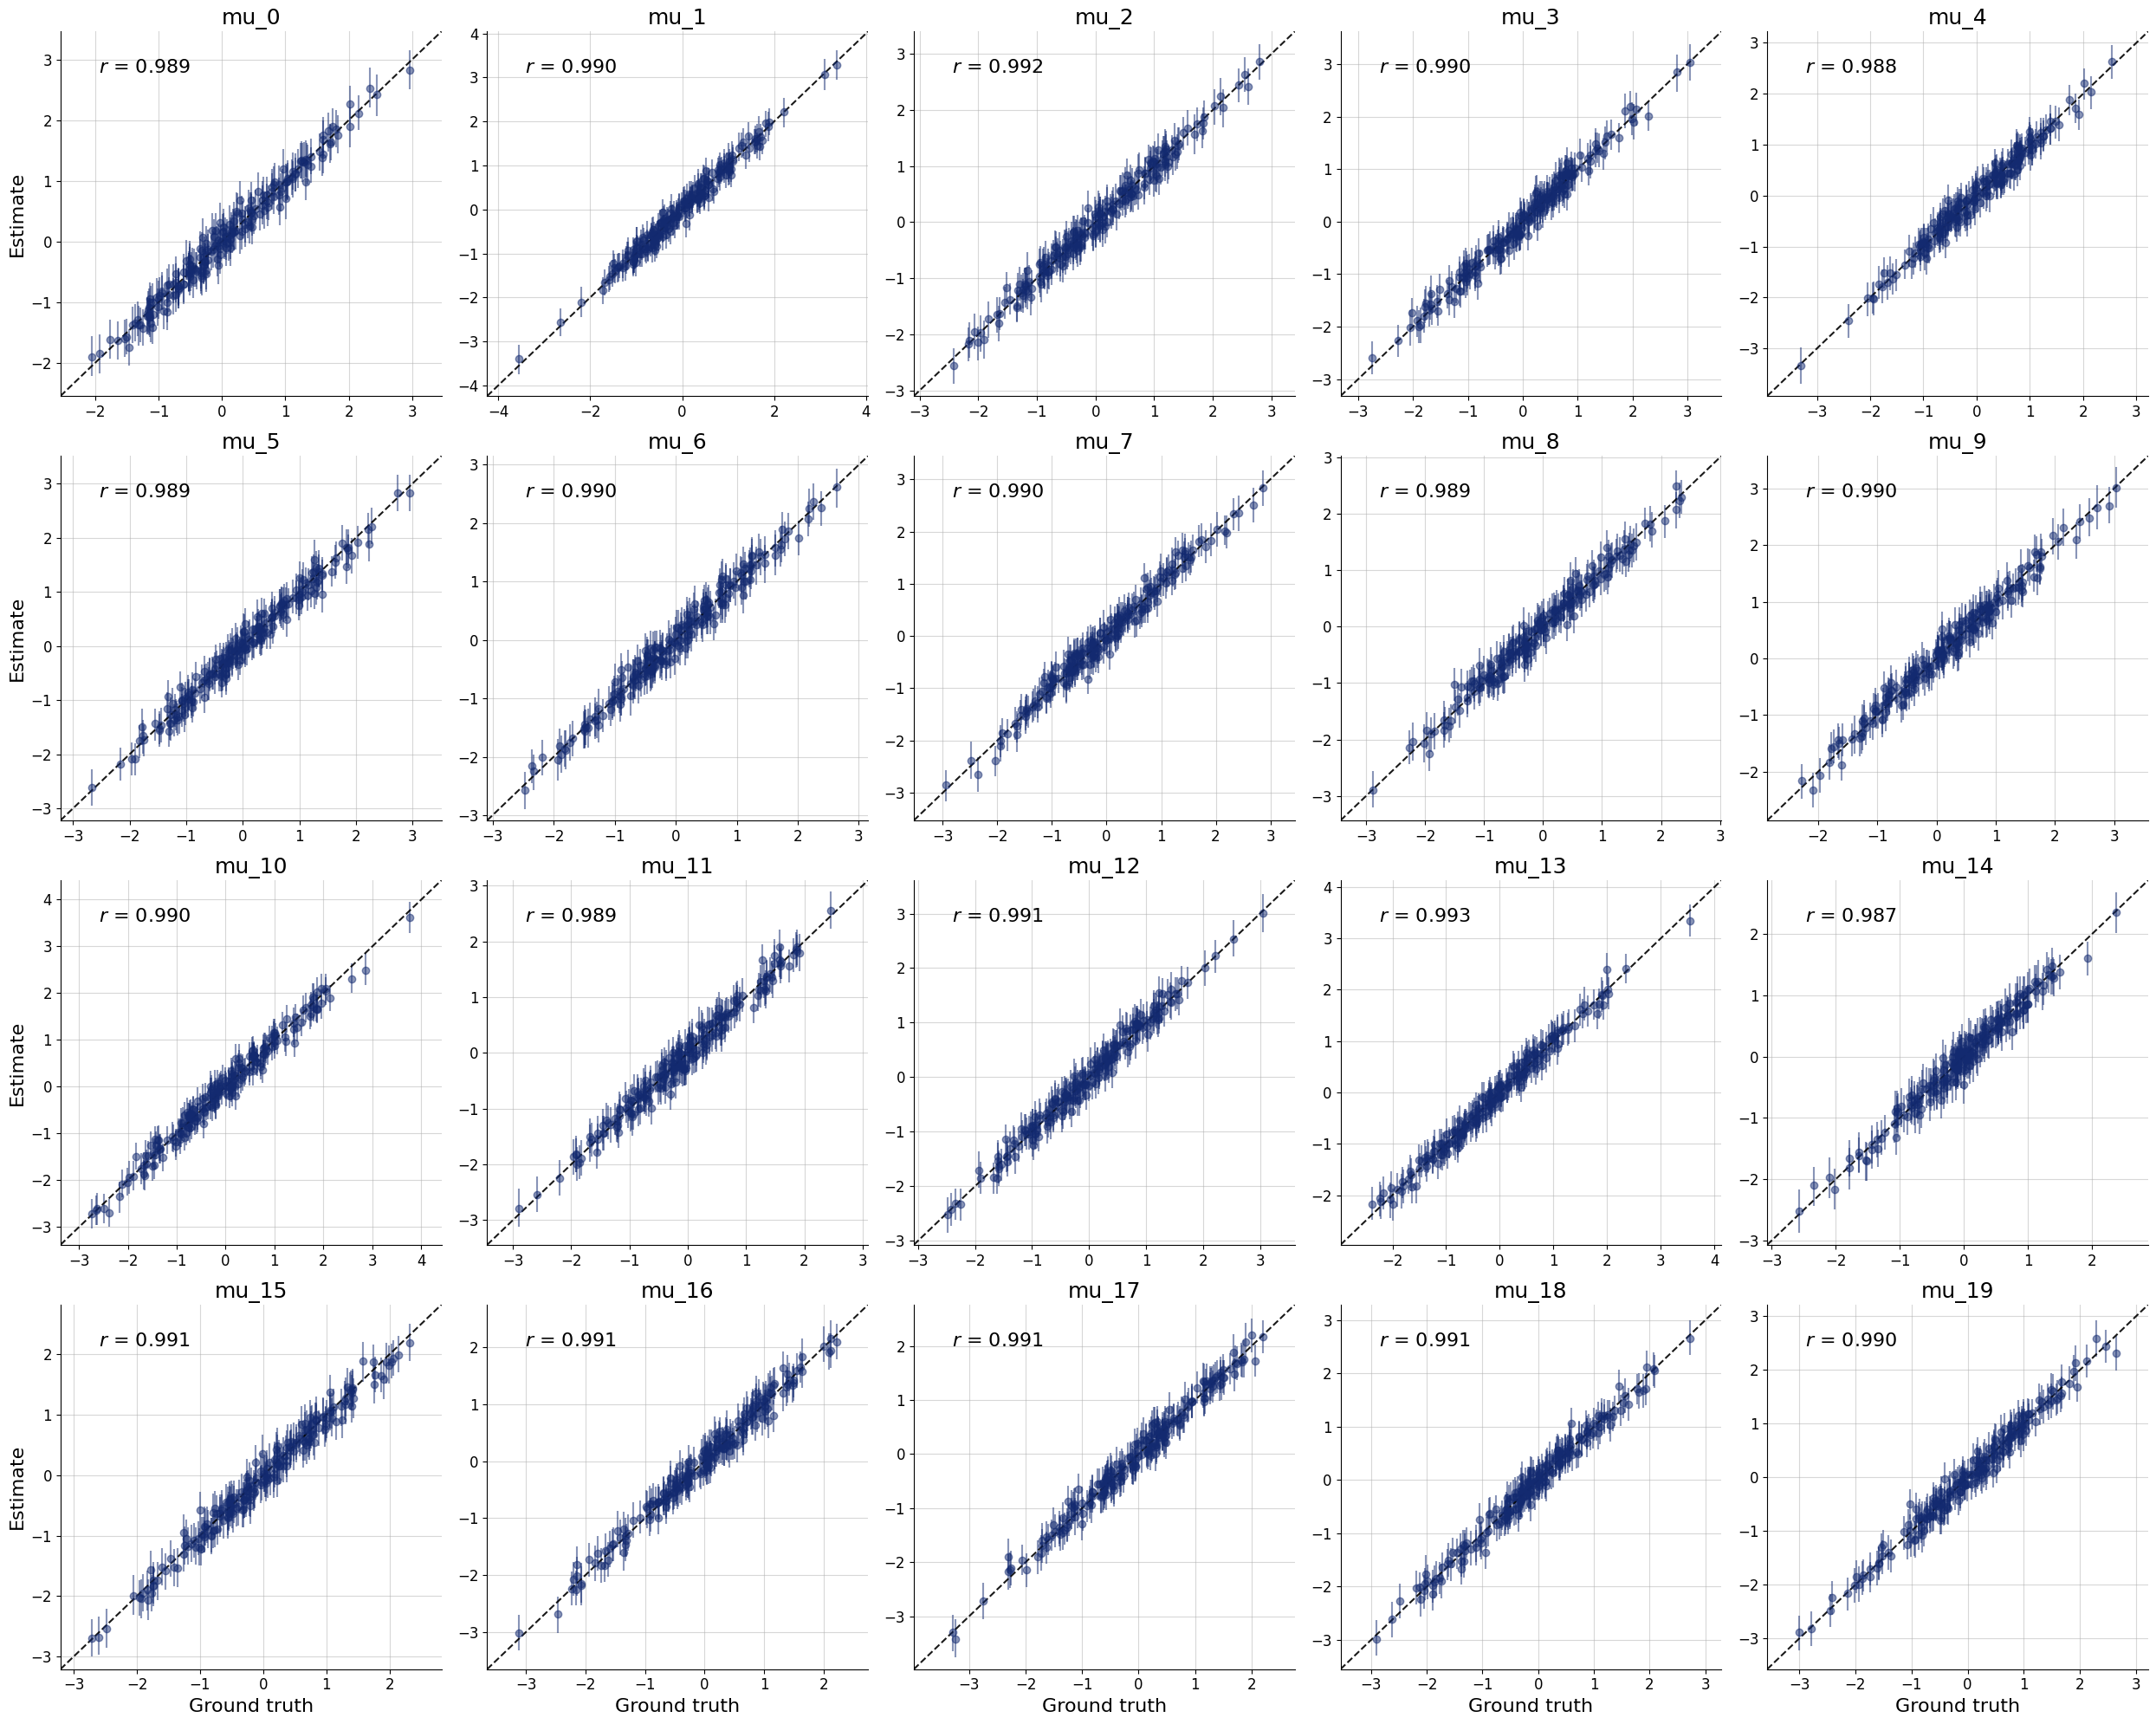

In [13]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)